# Project:  Circuit Breaker Vibration Signal - data exploration - 1

## Introdcution:
   
Circuit breakers are critical components in power systems, functioning as mechanical switching devices that protect electrical circuits from damage caused by overloads or short circuits.

Vibration-based condition monitoring is a non-invasive technique that allows us to detect the degradation process and assess the mechanical health of the equipment over time.

But, unlike other rotating machinery, the circuit breaker has a unique operational mechanism. Their vibration signals raise from dynamic switching actions (opening/closing):  These actions generate **transient, non-stationary, and non-linear** vibration signals. These characteristics make difficult for us to deal with the vibration data, for example,  **simple time-domain features (e.g., mean, RMS, kurtosis) are often insufficient or misleading due to the non-stationary nature of the data.**

The aim of this project is to explore and analyze the vibration data collected from vacuum circuit breakers (VCBs) to better understand signal patterns during degradation. This serves as a foundation for future health indicator development or predictive maintenance tasks.

## Data: "RUN-TO-FAILURE VACUUM CIRCUIT BREAKER MECHANICAL TEST DATASET"

This dataset is from ETHz High Voltage Laboratory: https://www.research-collection.ethz.ch/handle/20.500.11850/544221.

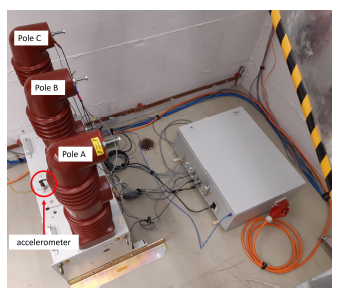


The vibration signal is meatured by accelerometer 786A. The experiment consists of three stages for each cycle: close operation, open operation, and motor charging.  For puerpose of degradation... only close operation data is used for this project. 

- Spring-operated ABB VD4 vacuum circuit breaker (VCB) Type 3612-16
- Run-to-failure data with more than 25,000 open and close operations (2,688 – 28,683 operations)
- Close and open operations are recorded in 300 kHz for 200 ms (60 000 sample points)
- Note: For this analysis, only the Close Operation signals are used, as they are most indicative of mechanical degradation.





# 0. Load Dependencies

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats

from scipy.fft import fft, fftfreq
from scipy.stats import entropy

# 1. Load Data

In [5]:
file_dir_1 = "../Dataset/close_operation_full/close_operation_2688_8745/close_operation_2688_8745"
file_dir_2 = "../Dataset/close_operation_full/close_operation_8746_18762/close_operation_8746_18762"
file_dir_3 = "../Dataset/close_operation_full/close_operation_18763_28684/close_operation_18763_28684"

def extract_operation_number(filename):
    parts = filename.split("_")  
    return int(parts[1])   

files_1 = sorted(os.listdir(file_dir_1), key=extract_operation_number)
files_2 = sorted(os.listdir(file_dir_2), key=extract_operation_number)
files_3 = sorted(os.listdir(file_dir_3), key=extract_operation_number)

len(files_1), len(files_2), len(files_3)



(6057, 10017, 9919)

In [6]:
print("The totle number of files: ", len(files_1) + len(files_2) + len(files_3))

The totle number of files:  25993


# 2. Let's take a look at several vibration signals in this data set

- File 2688: the first vibration in this data set
- File 8746
- File 18763
- File   

## 2.1 File 2688 - first vibration data

In [7]:
# load the first file
files_1_1 = os.path.join(file_dir_1, files_1[0])
data_1_1 = np.load(files_1_1)

data_1_1.shape

(60000, 9)

In [8]:
files_1[0]

'close_2688_2021-05-20_10-22-56.npy'

In [9]:
# convert this file into a df
columns = [
    "time", "trigger", "contact seperation A", "contact seperation B", "contact seperation C",
    "coil current open", "coil current close", "accel_786A", "motor_charging_current"]
df_1_1 = pd.DataFrame(data_1_1, columns=columns)
df_1_1

,time,trigger,contact seperation A,contact seperation B,contact seperation C,coil current open,coil current close,accel_786A,motor_charging_current
0,0.000000,3.224658,9.389543,9.419387,9.355686,0.015015,0.025016,0.014963,-0.004999
1,0.000003,3.200601,9.437078,9.439322,9.395721,0.012513,-0.007505,0.002494,-0.089978
2,0.000007,3.200601,9.301976,9.446798,9.398224,-0.015015,0.015009,0.032419,-0.042489
3,0.000010,3.215637,9.422067,9.484177,9.420743,-0.002503,0.020013,-0.024938,-0.027493
4,0.000013,3.231675,9.429572,9.481685,9.383210,0.062563,0.037523,0.007481,-0.007498
...,...,...,...,...,...,...,...,...,...
59995,0.199783,0.013031,0.022517,0.049838,0.017515,0.045045,0.027517,0.009975,0.014996
59996,0.199787,0.002005,-0.045034,-0.007476,0.027524,0.052553,0.030019,0.082294,0.019995
59997,0.199790,0.016038,0.015011,0.049838,-0.035031,0.062563,-0.042527,0.037406,-0.004999
59998,0.199793,0.017040,-0.002502,-0.004984,-0.042537,0.015015,-0.010006,0.037406,-0.039990


In [10]:
df_1_1['time'] = df_1_1['time'] * 1000

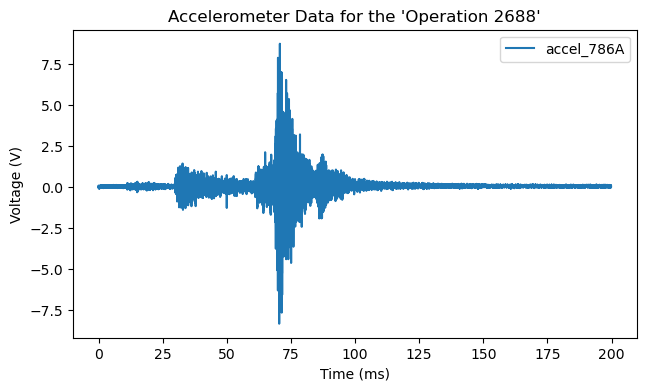

In [11]:
# see the vibration signal
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(df_1_1["time"], df_1_1["accel_786A"], label="accel_786A")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.legend()


plt.title("Accelerometer Data for the 'Operation 2688'")
plt.show()

## 2.2  File 8746

In [13]:
files_2[0]

'close_8746_2021-06-27_23-25-00.npy'

In [17]:
columns = [
    "time", "trigger", "contact seperation A", "contact seperation B", "contact seperation C",
    "coil current open", "coil current close", "accel_786A", "unknown", "motor_charging_current"]

In [18]:
# load the file
files_2_1 = os.path.join(file_dir_2, files_2[7659])
data_2_1 = np.load(files_2_1)

df_2_1 = pd.DataFrame(data_2_1, columns=columns)
df_2_1['time'] = df_2_1['time'] * 1000

In [19]:
df_2_1

,time,trigger,contact seperation A,contact seperation B,contact seperation C,coil current open,coil current close,accel_786A,unknown,motor_charging_current
0,0.00000,3.241465,9.443542,9.486541,9.546534,-0.005005,0.002502,0.052369,-0.069983,0.042585
1,0.00334,3.207575,9.506064,9.511466,9.439100,0.065065,-0.072545,0.077307,-0.042489,0.032565
2,0.00668,3.190630,9.496061,9.464108,9.501561,0.005005,0.010006,0.047382,-0.034991,0.050100
3,0.01002,3.196611,9.498562,9.464108,9.486571,0.007508,-0.020013,0.044888,-0.019995,0.027555
4,0.01336,3.220533,9.443542,9.474078,9.461587,0.047548,-0.040025,0.077307,-0.077481,-0.005010
...,...,...,...,...,...,...,...,...,...,...
59995,200.38330,0.002990,0.020008,-0.014955,-0.019988,0.040040,-0.020013,0.112219,-0.072482,0.015030
59996,200.38664,0.001994,-0.057522,-0.012463,-0.047470,0.042543,0.050031,0.069825,-0.004999,-0.037575
59997,200.38998,0.003987,-0.060023,0.029910,-0.039975,0.015015,0.027517,0.099751,-0.009998,0.005010
59998,200.39332,0.005981,0.030011,-0.024925,-0.024984,0.055055,-0.017511,0.134663,0.004999,-0.005010


In [20]:
df_2_1['accel_786A'].mean()

0.07665989186315177

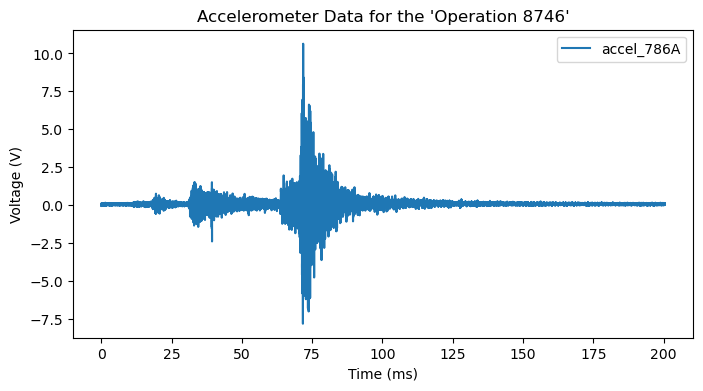

In [22]:
plt.figure(figsize=(8, 4))

plt.plot(df_2_1["time"], df_2_1["accel_786A"], label="accel_786A")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.legend()


plt.title("Accelerometer Data for the 'Operation 8746'")
plt.show()

## 2.3 File 18763

In [16]:
files_3[0]

'close_18763_2021-08-09_04-35-35.npy'

In [23]:
files_3_1 = os.path.join(file_dir_3, files_3[0])
data_3_1 = np.load(files_3_1)
data_3_1.shape

(60000, 10)

In [24]:
df_3_1 = pd.DataFrame(data_3_1)

In [25]:
columns_1 = columns = [
    "time", "trigger", "contact seperation A", "contact seperation B", "contact seperation C",
    "coil current open", "coil current close", "accel_786A", 'unknown', "motor_charging_current"]

In [26]:
# load the first file
files_3_1 = os.path.join(file_dir_3, files_3[0])
data_3_1 = np.load(files_3_1)

df_3_1 = pd.DataFrame(data_3_1, columns=columns_1)
df_3_1['time'] = df_3_1['time'] * 1000

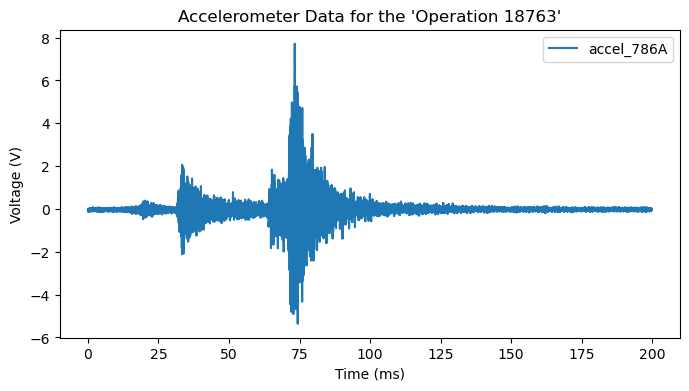

In [27]:
plt.figure(figsize=(8, 4))

plt.plot(df_3_1["time"], df_3_1["accel_786A"], label="accel_786A")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.legend()


plt.title("Accelerometer Data for the 'Operation 18763'")
plt.show()

## 2.4 File 28684 - failure time file

In [28]:
files_3[-1]

'close_28684_2021-09-04_17-49-29.npy'

In [29]:
files_3_last = os.path.join(file_dir_3, files_3[-1])
data_3_last = np.load(files_3_last)

df_3_last = pd.DataFrame(data_3_last, columns=columns_1)
df_3_last['time'] = df_3_last['time'] * 1000

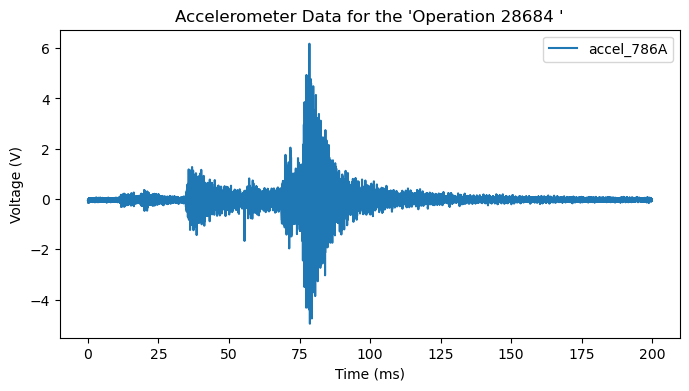

In [30]:
plt.figure(figsize=(8, 4))

plt.plot(df_3_last["time"], df_3_last["accel_786A"], label="accel_786A")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.legend()


plt.title("Accelerometer Data for the 'Operation 28684 '")
plt.show()

## 2.5 Plot the above vibration signals at once

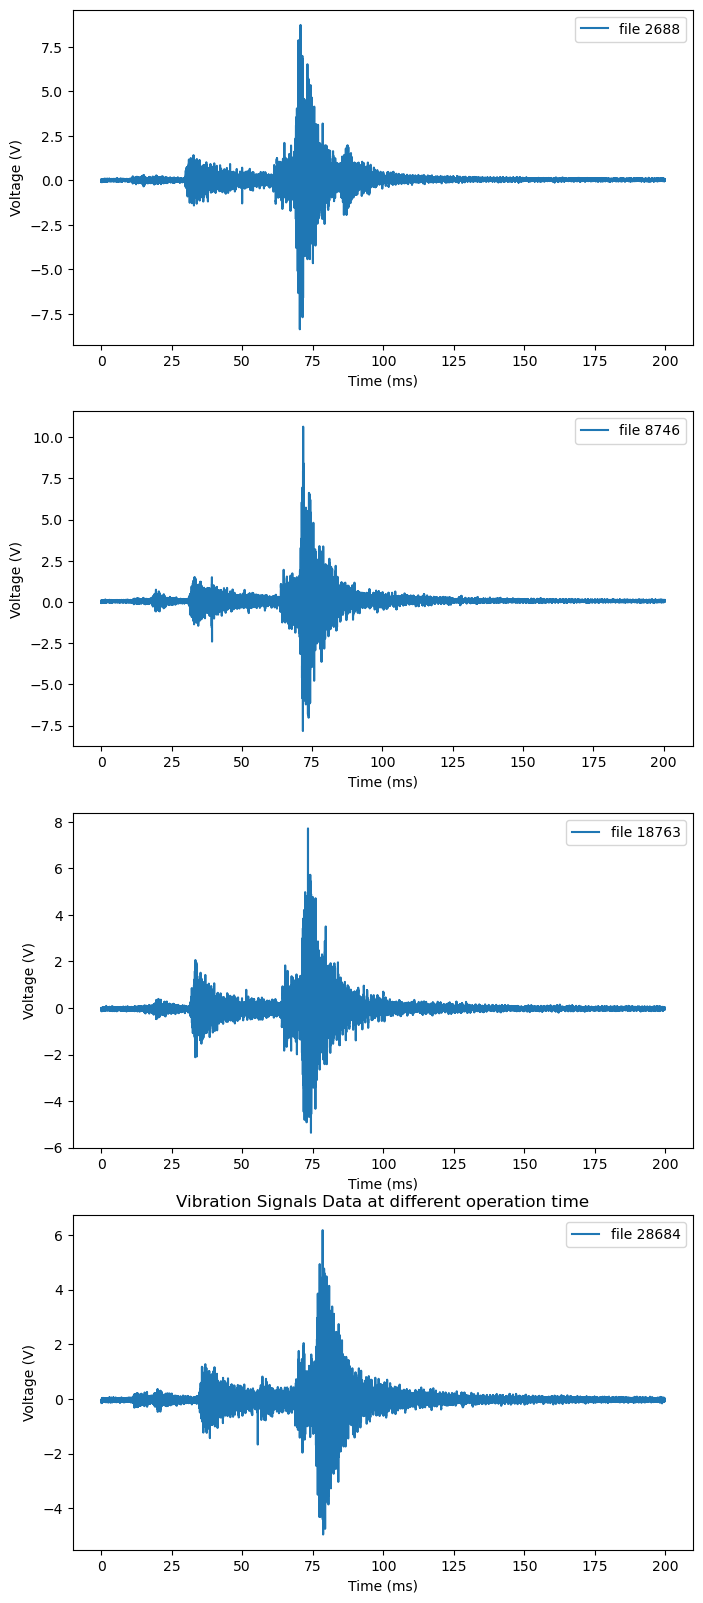

In [33]:

plt.figure(figsize=(8, 20))

plt.subplot(4, 1, 1)
plt.plot(df_1_1["time"], df_1_1["accel_786A"], label="file 2688")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(df_2_1["time"], df_2_1["accel_786A"], label="file 8746")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(df_3_1["time"], df_3_1["accel_786A"], label="file 18763")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(df_3_last["time"], df_3_last["accel_786A"], label="file 28684")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.legend()


plt.title("Vibration Signals Data at different operation time")
plt.show()  


After plotting these vibrations, we can see it is not that easy (as distinct as bearing signals) to detect the degradation process from the vibrations, whether in the stationary phase, early stage of the degradation, or eventually the final failure time.

# 3. Extract all vibration data

In [34]:
data_dict_1 = {}

for file in files_1:
    file_path = os.path.join(file_dir_1, file)
    
    data = np.load(file_path)
    
    if data.shape[1] == 9:
        selected_column = data[:, -2] 
    elif data.shape[1] == 10:
        selected_column = data[:, -3] 
    elif data.shape[1] == 13:
        selected_column = data[:, -6] 
    else:
        print(f"Skip {file} due to unexpected shape {data.shape}")
        continue

    data_dict_1[file] = selected_column

print("Data extraction done")


data_1 = np.array(list(data_dict_1.values()))
print("Data Shape:", data_1.shape) 


Data extraction done
Data Shape: (6057, 60000)


In [35]:
np.save("data_2688_8745.npy", data_1)

In [37]:
data_dict_2 = {}

for file in files_2:
    file_path = os.path.join(file_dir_2, file)
    
    data = np.load(file_path)
    
    if data.shape[1] == 9:
        selected_column = data[:, -2] 
    elif data.shape[1] == 10:
        selected_column = data[:, -3] 
    elif data.shape[1] == 13:
        selected_column = data[:, -6] 
    else:
        print(f"Skip {file} due to unexpected shape {data.shape}")
        continue 

    data_dict_2[file] = selected_column

print("Data extraction done")

data_2 = np.array(list(data_dict_2.values()))
print("Data Shape:", data_2.shape)

Data extraction done
Data Shape: (10017, 60000)


In [38]:
np.save("data_8746_18762.npy", data_2)

In [39]:
data_dict_3 = {}

for file in files_3:
    file_path = os.path.join(file_dir_3, file)
    
    data = np.load(file_path)

    if data.shape[1] == 9:
        selected_column = data[:, -2] 
    elif data.shape[1] == 10:
        selected_column = data[:, -3] 
    elif data.shape[1] == 13:
        selected_column = data[:, -6] 
    else:
        print(f"Skip {file} due to unexpected shape {data.shape}")
        continue 
    data_dict_3[file] = selected_column

print("Data extraction done")


Data extraction done


In [40]:
save_path = "data_3_chunks"

if not os.path.exists(save_path):
    os.makedirs(save_path)

for file, array in data_dict_3.items():
    np.save(os.path.join(save_path, f"{file}.npy"), array.astype(np.float32))  # Save in float32

print(f"Data folder 3 saved in chunks at {save_path}")


Data folder 3 saved in chunks at data_3_chunks


# 4. Extract time-domain features

In [43]:
# Load the saved vibration data
data_1 = np.load("data_2688_8745.npy")
data_2 = np.load("data_8746_18762.npy")
data_chunks_path = "data_3_chunks"
data_chunks_list = []

for file in sorted(os.listdir(data_chunks_path)):  
    if file.endswith(".npy"):
        chunk = np.load(os.path.join(data_chunks_path, file))
        data_chunks_list.append(chunk)

data_chunks = np.array(data_chunks_list)

print("data_1 shape:", data_1.shape)
print("data_2 shape:", data_2.shape)
print("data_3 shape:", data_chunks.shape)

data_1 shape: (6057, 60000)
data_2 shape: (10017, 60000)
data_3 shape: (9919, 60000)


In [46]:
data = np.vstack([data_1, data_2, data_chunks])

print("Stacked data Shape:", data.shape)

MemoryError: Unable to allocate 11.6 GiB for an array with shape (25993, 60000) and data type float64